# EDA de la entrega de tarjetas del sistema de transporte de Quito
**Programación y Análisis de Datos (MIACD02P01) - Proyecto final: Dashboard EDA por profesión**

## Contexto
**Profesión:** Analista de Datos - Empresa Pública Metropolitana de Transporte de Pasajeros Quito

**Problema real:** el sistema Trolebús y Ecovía de Quito entrega tarjetas de transporte en estaciones, terminales, paradas, eventos y puntos de venta. Cada punto necesita **personal** y **stock de tarjetas**, pero la demanda no es igual en todos los lugares ni en todos los días.

**Datos:** registros diarios de entrega de tarjetas (marzo a septiembre de 2026) en el archivo `resumen_total_tarjetas.xlsx`, más un archivo con las coordenadas de las estaciones principales. Son **datos agregados** (por día y punto), sin información de personas.

**Flujo del análisis (7 pasos):**
1. Pregunta -> 2. Estructura -> 3. Univariado -> 4. Bivariado -> 5. Faltantes, duplicados y atípicos -> 6. Segmentación -> 7. Hallazgos

## Paso 1. La pregunta de análisis
Antes de tocar los datos definimos qué queremos responder y qué decisión queremos apoyar.

> **Pregunta principal:** ¿en qué estaciones, días y canales se concentra la entrega de tarjetas según su perfil (Universal, Reducida y Preferencial), y cómo debería distribuirse el inventario de tarjetas entre estaciones, paradas y eventos del sistema de transporte de Quito?

**Preguntas de apoyo**
1. ¿Qué estaciones entregan más tarjetas?
2. ¿Qué perfil de tarjeta entrega cada estación?
3. ¿Qué canal (estación, terminal, parada, evento o punto de venta) entrega más tarjetas por jornada?
4. ¿Hay días de la semana con más demanda?
5. ¿Cómo evolucionó la entrega de tarjetas desde el lanzamiento?

**Decisión que se quiere apoyar:** cuántas tarjetas, de qué perfil y en qué punto y día conviene tener disponibles.

## Preparación del entorno

In [1]:
# Librerías
import sys # para indicarle a Python dónde está la carpeta src/
from pathlib import Path # manejo de rutas compatible con Windows, Mac y Linux

import numpy as np # cálculos numéricos
import pandas as pd # tablas de datos (DataFrames)
import matplotlib.pyplot as plt # gráficos base
import seaborn as sns # gráficos estadísticos sobre matplotlib
from scipy import stats # pruebas estadísticas (Kruskal, Spearman, chi-cuadrado)

# Opciones de presentación
sns.set_theme(style="whitegrid") # estilo limpio para los gráficos
pd.set_option("display.float_format", lambda x: f"{x:,.2f}") # números con 2 decimales y separador de miles
pd.set_option("display.max_columns", 40) # mostrar todas las columnas

# Ubicar la raíz del proyecto
# Si el notebook se abre desde notebooks/, la raíz es la carpeta de arriba
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.append(str(RAIZ)) # permite importar src.limpieza al final

RUTA_EXCEL = RAIZ / "data" / "crudos" / "resumen_total_tarjetas.xlsx" # datos en bruto
RUTA_ESTACIONES = RAIZ / "data" / "crudos" / "estaciones_transporte_quito.csv" # coordenadas en bruto
print("Carpeta del proyecto:", RAIZ.name)
print("¿Existe el Excel?", RUTA_EXCEL.exists())

Carpeta del proyecto: proyecto_tarjetas_quito
¿Existe el Excel? True


## Paso 2. Análisis de estructura
### 2.1 ¿Qué contiene el archivo?

In [2]:
# Un Excel puede tener varias hojas: primero vemos cuáles hay
hojas = pd.ExcelFile(RUTA_EXCEL).sheet_names # lista con los nombres de las hojas
hojas

['DETALLE_TARJETAS_nuevo',
 'DETALLE_TARJETAS',
 'DETALLE_TARJETAS_FINAL',
 'RESUMEN_PARADAS',
 'REPORTE_WEB',
 'RESUMEN_CORREDOR_TARJETAS',
 'RESUMEN_MENSUAL_TARJETAS',
 'ORIGEN_TARJETAS',
 'EVOLUCION_DIARIA',
 'DISTRIBUCION_ESTACION',
 'KPI_TARJETAS']

Por indicación de la fuente trabajamos con la hoja **`DETALLE_TARJETAS_nuevo`**, que tiene **un registro por punto y por día**. Las demás hojas son versiones procesadas o resúmenes derivados.

In [3]:
# Leemos la hoja de detalle SIN modificarla: esta es la data en bruto
crudo = pd.read_excel(RUTA_EXCEL, sheet_name="DETALLE_TARJETAS_nuevo")

print("Filas y columnas:", crudo.shape) # (número de filas, número de columnas)
crudo.head() # primeras 5 filas para conocer el formato

Filas y columnas: (1664, 14)


,fecha,corredor,estacion_o_evento,,numero_planilla,valor_tarifa_tu,cantidad_tu,valor_tarifa_tr,cantidad_tr,valor_tarifa_tp,cantidad_tp,total_tarjetas,horario_extendido,total_dinero
0,2026-03-03,Trole Sur,El Recreo,DISTRIBUCION_MUNICIPIO,SIN_CODIGO,0.35,0,0.17,27000,0.10,0,27000,0,0.00
1,2026-03-06,Ecovía Norte,Estación Río Coca,NORMAL,NaN,0.35,0,0.17,0,0.10,0,0,0,0.00
2,2026-03-06,Sur Oriental,Guamaní,NORMAL,NaN,0.35,0,0.17,0,0.10,0,0,0,0.00
3,2026-03-06,Sur Oriental,Playón de la Marín,NORMAL,NaN,0.35,0,0.17,0,0.10,0,0,0,0.00
4,2026-03-06,Trole Norte,Estación Labrador,NORMAL,NaN,0.35,0,0.17,0,0.10,0,0,0,0.00


In [4]:
# Tipo de dato de cada columna, cuántos valores no nulos tiene y memoria usada
crudo.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              1664 non-null   datetime64[us]
 1   corredor           1664 non-null   str           
 2   estacion_o_evento  1664 non-null   str           
 3                      1664 non-null   str           
 4   numero_planilla    1453 non-null   str           
 5   valor_tarifa_tu    1664 non-null   float64       
 6   cantidad_tu        1664 non-null   int64         
 7   valor_tarifa_tr    1664 non-null   float64       
 8   cantidad_tr        1664 non-null   int64         
 9   valor_tarifa_tp    1664 non-null   float64       
 10  cantidad_tp        1664 non-null   int64         
 11  total_tarjetas     1664 non-null   int64         
 12  horario_extendido  1664 non-null   int64         
 13  total_dinero       1664 non-null   float64       
dtypes: datetime64[us](1

In [5]:
# Mostramos los nombres de columna entre comillas para ver espacios ocultos
[repr(c) for c in crudo.columns]

["'fecha'",
 "'corredor'",
 "'estacion_o_evento'",
 "'   '",
 "'numero_planilla'",
 "'valor_tarifa_tu'",
 "'cantidad_tu'",
 "'valor_tarifa_tr'",
 "'cantidad_tr'",
 "'valor_tarifa_tp'",
 "'cantidad_tp'",
 "'total_tarjetas'",
 "'horario_extendido'",
 "'total_dinero'"]

Observación: **Problema de estructura:** la cuarta columna **no tiene nombre**: su encabezado son tres espacios en blanco (`'   '`). Por sus valores (NORMAL, PARADA, EVENTO, PUNTO_VENTA…) es el **tipo de registro**.

In [6]:
# Valores únicos por columna: 1 -> columna constante - muchos -> identificador o numérica
crudo.nunique().sort_values()

valor_tarifa_tr         1
valor_tarifa_tu         1
valor_tarifa_tp         1
corredor                4
                        5
cantidad_tp            25
horario_extendido      27
cantidad_tr            99
estacion_o_evento     103
fecha                 201
cantidad_tu           228
total_tarjetas        278
total_dinero          445
numero_planilla      1431
dtype: int64

In [7]:
# Rango de fechas cubierto y número de días distintos
print("Desde:", crudo["fecha"].min().date(), "| Hasta:", crudo["fecha"].max().date())
print("Días con registros:", crudo["fecha"].nunique())

Desde: 2026-03-03 | Hasta: 2026-09-21
Días con registros: 201


### 2.2 ¿Qué perfil de tarjeta es cada columna de cantidad?
Las columnas `cantidad_tu`, `cantidad_tr` y `cantidad_tp` usan siglas. **La fuente de los datos confirmó** su significado:

| Sufijo | Perfil | Valor en la columna `valor_tarifa_*` |
|---|---|---|
| `tu` | Tarjeta **Universal** | 0,35 |
| `tr` | Tarjeta **Reducida** | 0,17 |
| `tp` | Tarjeta **Preferencial** | 0,10 |

Observación: Según la misma fuente, los valores 0,35 / 0,17 / 0,10 **no son precios**: solo identifican el perfil. Aunque sean números, **no son variables numéricas** y no se usan en cálculos.

In [8]:
# Comprobamos que los valor_tarifa_* son constantes (no varían entre filas)
crudo[["valor_tarifa_tu", "valor_tarifa_tr", "valor_tarifa_tp"]].nunique()

valor_tarifa_tu    1
valor_tarifa_tr    1
valor_tarifa_tp    1
dtype: int64

### 2.3 Diccionario de variables (datos en bruto)

| Variable | Tipo | Descripción | ¿Se usa? |
|---|---|---|---|
| `fecha` | Fecha | Día del registro | Sí |
| `corredor` | Categórica (4) | Trole Sur, Trole Norte, Ecovía Norte, Sur Oriental | Sí |
| `estacion_o_evento` | Categórica (~100) | Punto de entrega | Sí |
| `'   '` (sin nombre) | Categórica (5) | Tipo de registro: NORMAL, PARADA, EVENTO, PUNTO_VENTA, DISTRIBUCION_MUNICIPIO | Sí, renombrada |
| `numero_planilla` | Texto | Código de la planilla física | Solo control |
| `valor_tarifa_tu / tr / tp` | Constantes | Identifican el perfil (no son precios) | No |
| `cantidad_tu / tr / tp` | Numérica discreta | Tarjetas Universal / Reducida / Preferencial | Sí |
| `total_tarjetas` | Numérica discreta | Suma de los tres perfiles | Sí (variable principal) |
| `horario_extendido` | Numérica discreta | Tarjetas en horario extendido (*por confirmar con la fuente*) | Sí, con cautela |
| `total_dinero` | Numérica continua | **Sin definición clara** | No (ver 2.4) |

**Unidad de observación:** un registro de entrega en un punto y en una fecha.

### 2.4 Ajuste de nombres, columnas y tipos

In [9]:
# Comprobamos que la suma de los perfiles coincide con total_tarjetas en todas las filas
suma_perfiles = crudo["cantidad_tu"] + crudo["cantidad_tr"] + crudo["cantidad_tp"]
print("Filas donde la suma NO coincide:", (suma_perfiles != crudo["total_tarjetas"]).sum())

Filas donde la suma NO coincide: 0


In [10]:
# 1) Nombres claros
sin_nombre = [c for c in crudo.columns if str(c).strip() == ""] # la columna con encabezado vacío
df = crudo.rename(columns={
    sin_nombre[0]: "tipo_registro", # columna sin nombre -> tipo de registro
    "cantidad_tu": "tarjetas_universal", # perfiles confirmados por la fuente
    "cantidad_tr": "tarjetas_reducida",
    "cantidad_tp": "tarjetas_preferencial",
})

### ¿Qué mide `total_dinero`?
Antes de usar una variable hay que saber qué mide. Probamos la interpretación más natural: tarjetas × valor de cada perfil.

In [11]:
esperado = (crudo["cantidad_tu"] * crudo["valor_tarifa_tu"] # dinero esperado si fuera
            + crudo["cantidad_tr"] * crudo["valor_tarifa_tr"] # tarjetas × valor
            + crudo["cantidad_tp"] * crudo["valor_tarifa_tp"])
coincide = (esperado.round(2) == crudo["total_dinero"].round(2))
print(f"Registros donde total_dinero = tarjetas × valor: {coincide.sum()} de {len(crudo)}")

# ¿En qué tipos de registro aparece en $0 aunque se entregaron tarjetas?
cero = (crudo["total_dinero"] == 0) & (crudo["total_tarjetas"] > 0)
(cero.groupby(crudo[sin_nombre[0]]).mean() * 100).round(1).rename("% con total_dinero = $0")

Registros donde total_dinero = tarjetas × valor: 27 de 1664


   
DISTRIBUCION_MUNICIPIO   100.00
EVENTO                     4.10
NORMAL                    12.80
PARADA                    96.50
PUNTO_VENTA               62.50
Name: % con total_dinero = $0, dtype: float64

`total_dinero` **no coincide** con tarjetas × valor, aparece en **$0 en casi todas las paradas** aunque se entregaron tarjetas, y **su definición no está clara**. Usarla llevaría a conclusiones sin sustento, así que **se excluye del análisis** y queda documentada como limitación.

In [12]:
# 2) Eliminar columnas sin información (0 o 1 valor distinto) y la variable sin definición clara
sin_info = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=sin_info + ["total_dinero"])
print("Columnas eliminadas:", sin_info + ["total_dinero"])
print("Columnas que quedan:", list(df.columns))

Columnas eliminadas: ['valor_tarifa_tu', 'valor_tarifa_tr', 'valor_tarifa_tp', 'total_dinero']
Columnas que quedan: ['fecha', 'corredor', 'estacion_o_evento', 'tipo_registro', 'numero_planilla', 'tarjetas_universal', 'tarjetas_reducida', 'tarjetas_preferencial', 'total_tarjetas', 'horario_extendido']


La hoja no trae el **sistema** (Trolebús o Ecovía) ni el **tipo de ubicación** (estación, terminal, parada…), que son claves para segmentar. Los **derivamos** de columnas que sí están:
- **Sistema** ← corredor (Trole Sur y Trole Norte son Trolebús; Ecovía Norte y Sur Oriental son Ecovía).
- **Tipo de ubicación** ← tipo de registro (un registro NORMAL es una estación, salvo **Quitumbe**, que es un terminal terrestre).

In [13]:
# 3) Derivar sistema y tipo de ubicación
sistema_por_corredor = {"Trole Sur": "TROLEBUS", "Trole Norte": "TROLEBUS",
                        "Ecovía Norte": "ECOVIA", "Sur Oriental": "ECOVIA"}
tipo_por_registro = {"NORMAL": "ESTACION", "PARADA": "PARADA", "EVENTO": "EVENTO",
                     "PUNTO_VENTA": "PUNTO_VENTA", "DISTRIBUCION_MUNICIPIO": "ESTACION"}

df["sistema"] = df["corredor"].map(sistema_por_corredor)
df["tipo_ubicacion"] = df["tipo_registro"].map(tipo_por_registro)
df.loc[df["estacion_o_evento"].isin({"Quitumbe"}) & (df["tipo_registro"] == "NORMAL"),
       "tipo_ubicacion"] = "TERMINAL" # Quitumbe es un terminal
pd.crosstab(df["tipo_registro"], df["tipo_ubicacion"]) # comprobamos la derivación

tipo_ubicacion,ESTACION,EVENTO,PARADA,PUNTO_VENTA,TERMINAL
tipo_registro,,,,,
DISTRIBUCION_MUNICIPIO,1,0,0,0,0
EVENTO,0,195,0,0,0
NORMAL,999,0,0,0,200
PARADA,0,0,229,0,0
PUNTO_VENTA,0,0,0,40,0


In [14]:
# Validación: la hoja DETALLE_TARJETAS_FINAL sí trae sistema y tipo_ubicacion.
# Comparamos nuestras columnas derivadas con las de esa hoja, registro por registro.
final = pd.read_excel(RUTA_EXCEL, sheet_name="DETALLE_TARJETAS_FINAL")
clave = ["fecha", "estacion_o_evento", "tipo_registro", "total_tarjetas"] # identifica cada registro
comparacion = df[clave + ["sistema", "tipo_ubicacion"]].merge(
    final[clave + ["sistema", "tipo_ubicacion"]], on=clave, suffixes=("", "_final"))
print("Registros comparados:", len(comparacion))
print("Diferencias en sistema:", (comparacion["sistema"] != comparacion["sistema_final"]).sum())
print("Diferencias en tipo de ubicación:",
      (comparacion["tipo_ubicacion"] != comparacion["tipo_ubicacion_final"]).sum())

Registros comparados: 1664
Diferencias en sistema: 0
Diferencias en tipo de ubicación: 0


Las columnas derivadas coinciden **en todos los registros** con las de la otra hoja: la derivación es correcta.

In [15]:
memoria_antes = df.memory_usage(deep=True).sum() / 1024 # memoria en KB antes del ajuste

# 4) Texto con pocos valores distintos -> category (ocupa menos y agrupa mejor)
for col in ["corredor", "sistema", "tipo_ubicacion", "tipo_registro"]:
    df[col] = df[col].astype("category")

# 5) Variables de tiempo derivadas de la fecha
df["fecha"] = pd.to_datetime(df["fecha"]) # asegura el tipo fecha
df["mes"] = df["fecha"].dt.to_period("M").astype(str) # "2026-03", "2026-04", ...
df["semana"] = df["fecha"].dt.to_period("W").dt.start_time # lunes de cada semana
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
df["dia_semana"] = pd.Categorical( # día con orden lógico, no alfabético
    df["fecha"].dt.dayofweek.map(dict(enumerate(dias))), categories=dias, ordered=True)

memoria_despues = df.memory_usage(deep=True).sum() / 1024
print(f"Memoria: {memoria_antes:,.0f} KB -> {memoria_despues:,.0f} KB")
df.dtypes

Memoria: 235 KB -> 177 KB


fecha                    datetime64[us]
corredor                       category
estacion_o_evento                   str
tipo_registro                  category
numero_planilla                     str
tarjetas_universal                int64
tarjetas_reducida                 int64
tarjetas_preferencial             int64
total_tarjetas                    int64
horario_extendido                 int64
sistema                        category
tipo_ubicacion                 category
mes                                 str
semana                   datetime64[us]
dia_semana                     category
dtype: object

### 2.5 Decisión de alcance: ¿todos los registros son demanda del público?

In [16]:
# Revisamos los registros más grandes: ¿hay alguno fuera de escala?
df.nlargest(5, "total_tarjetas")[["fecha", "estacion_o_evento", "tipo_registro", "total_tarjetas"]]

,fecha,estacion_o_evento,tipo_registro,total_tarjetas
0,2026-03-03,El Recreo,DISTRIBUCION_MUNICIPIO,27000
162,2026-04-01,El Recreo,NORMAL,702
150,2026-03-30,El Recreo,NORMAL,616
156,2026-03-31,El Recreo,NORMAL,543
90,2026-03-20,El Recreo,NORMAL,466


El registro más grande (27.000 tarjetas en un día) es una **distribución masiva al municipio**, identificada así en `tipo_registro`. No es una entrega al público, por lo que **queda fuera del análisis de demanda**. Si se dejara, El Recreo parecería concentrar casi un tercio de todas las tarjetas.

In [17]:
# ¿De qué perfil son las 27.000 tarjetas de la distribución masiva?
masiva = df[df["tipo_registro"] == "DISTRIBUCION_MUNICIPIO"]
masiva[["tarjetas_universal", "tarjetas_reducida", "tarjetas_preferencial", "total_tarjetas"]]

,tarjetas_universal,tarjetas_reducida,tarjetas_preferencial,total_tarjetas
0,0,27000,0,27000


In [18]:
# ¿Cuánto cambiaría la media diaria de El Recreo si se dejara la distribución masiva?
recreo = df[df["estacion_o_evento"] == "El Recreo"]
media_con = recreo["total_tarjetas"].mean()                                            # con el registro de 27.000
media_sin = recreo.loc[recreo["tipo_registro"] != "DISTRIBUCION_MUNICIPIO", "total_tarjetas"].mean()
print(f"Media diaria de El Recreo: {media_sin:.0f} sin el registro -> {media_con:.0f} con el registro "
      f"(+{(media_con / media_sin - 1) * 100:.0f} %)")

Media diaria de El Recreo: 129 sin el registro -> 263 con el registro (+104 %)


In [19]:
# Excluimos la distribución al municipio y limpiamos la categoría que queda vacía
df = df[df["tipo_registro"] != "DISTRIBUCION_MUNICIPIO"].copy()
df["tipo_registro"] = df["tipo_registro"].cat.remove_unused_categories()
print("Registros para el análisis:", len(df))

Registros para el análisis: 1663


## Paso 3. Análisis univariado
Cada variable por sí sola: centro, dispersión y forma.
### 3.1 Variables numéricas

In [20]:
numericas = ["total_tarjetas", "tarjetas_universal", "tarjetas_reducida",
             "tarjetas_preferencial", "horario_extendido"]
resumen = df[numericas].describe().T # conteo, media, desviación, mínimo, cuartiles, máximo
resumen["asimetria"] = df[numericas].skew() # > 0: cola larga hacia valores altos
resumen

,count,mean,std,min,25%,50%,75%,max,asimetria
total_tarjetas,"1,663.00",72.60,78.23,0.00,26.00,47.00,86.00,702.00,2.54
tarjetas_universal,"1,663.00",55.19,58.79,0.00,19.00,37.00,66.00,500.00,2.40
tarjetas_reducida,"1,663.00",14.97,19.04,0.00,4.00,9.00,17.00,176.00,3.18
tarjetas_preferencial,"1,663.00",2.45,3.23,0.00,0.00,1.00,3.00,26.00,2.74
horario_extendido,"1,663.00",0.70,3.44,0.00,0.00,0.00,0.00,40.00,5.85


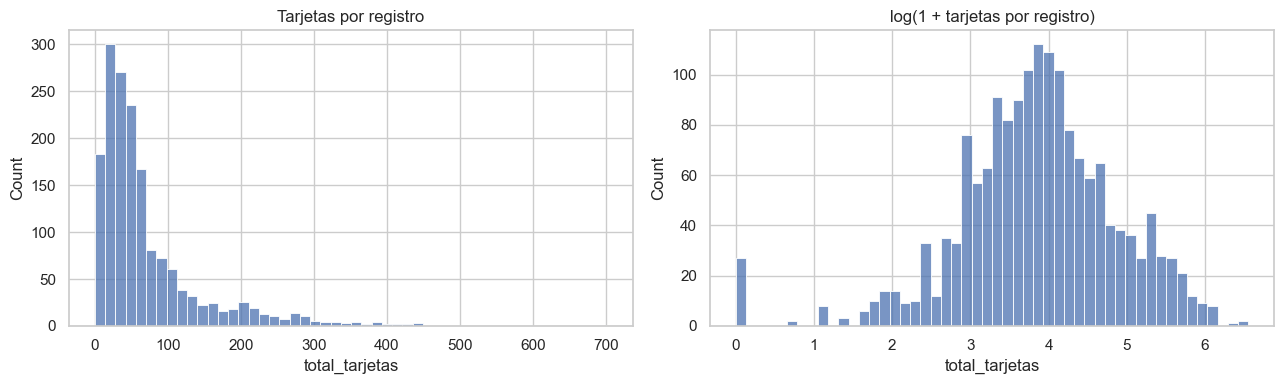

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4)) # dos gráficos lado a lado
sns.histplot(df["total_tarjetas"], bins=50, ax=ax[0]) # distribución original
ax[0].set_title("Tarjetas por registro")
sns.histplot(np.log1p(df["total_tarjetas"]), bins=50, ax=ax[1]) # log(1 + x): admite ceros
ax[1].set_title("log(1 + tarjetas por registro)")
plt.tight_layout(); plt.show()

In [22]:
# Comparamos media y mediana: si la media es mucho mayor, hay valores altos que la inflan
print(f"Media de tarjetas por registro:   {df['total_tarjetas'].mean():.1f}")
print(f"Mediana de tarjetas por registro: {df['total_tarjetas'].median():.1f}")

Media de tarjetas por registro:   72.6
Mediana de tarjetas por registro: 47.0


La distribución es **asimétrica a la derecha**: muchos registros con pocas tarjetas y unos pocos con cientos. La media queda por encima de la mediana, así que **usamos la mediana** para describir una jornada típica.

### 3.2 Perfiles de tarjeta

In [23]:
perfiles = ["tarjetas_universal", "tarjetas_reducida", "tarjetas_preferencial"]
mezcla = df[perfiles].sum() # total de tarjetas de cada perfil
(mezcla / mezcla.sum() * 100).round(1).rename("% de tarjetas")

tarjetas_universal      76.00
tarjetas_reducida       20.60
tarjetas_preferencial    3.40
Name: % de tarjetas, dtype: float64

### 3.3 Variables categóricas

In [24]:
# Porcentaje de registros en cada categoría
for col in ["tipo_ubicacion", "corredor", "sistema", "tipo_registro"]:
    print((df[col].value_counts(normalize=True) * 100).round(1), "\n")
print("Puntos de entrega distintos:", df["estacion_o_evento"].nunique())

tipo_ubicacion
ESTACION      60.10
PARADA        13.80
TERMINAL      12.00
EVENTO        11.70
PUNTO_VENTA    2.40
Name: proportion, dtype: float64 

corredor
Trole Sur      45.10
Sur Oriental   24.10
Trole Norte    16.10
Ecovía Norte   14.80
Name: proportion, dtype: float64 

sistema
TROLEBUS   61.20
ECOVIA     38.80
Name: proportion, dtype: float64 

tipo_registro
NORMAL        72.10
PARADA        13.80
EVENTO        11.70
PUNTO_VENTA    2.40
Name: proportion, dtype: float64 

Puntos de entrega distintos: 103


In [25]:
# ¿Cuántos días registra cada tipo de ubicación?
df.groupby("tipo_ubicacion", observed=True)["fecha"].nunique().rename("días con registros")

tipo_ubicacion
ESTACION       200
EVENTO         139
PARADA          77
PUNTO_VENTA     40
TERMINAL       200
Name: días con registros, dtype: int64

**Lectura:** las estaciones y el terminal registran casi todos los días (son fijos), mientras que eventos, paradas y puntos de venta aparecen solo algunos días. Eso importa para comparar **por jornada** y no por total.

## Paso 4. Análisis bivariado
### 4.1 ¿Qué tipo de ubicación entrega más tarjetas por jornada?

In [26]:
por_tipo = (df.groupby("tipo_ubicacion", observed=True)["total_tarjetas"]
              .agg(registros="count", mediana="median", total="sum") # tres medidas por tipo
              .sort_values("mediana", ascending=False))
por_tipo["%_del_total"] = por_tipo["total"] / por_tipo["total"].sum() * 100
por_tipo

,registros,mediana,total,%_del_total
tipo_ubicacion,,,,
EVENTO,195,105.00,25999,21.53
ESTACION,999,51.00,75411,62.46
TERMINAL,200,33.00,11175,9.26
PARADA,229,29.00,7873,6.52
PUNTO_VENTA,40,6.00,282,0.23


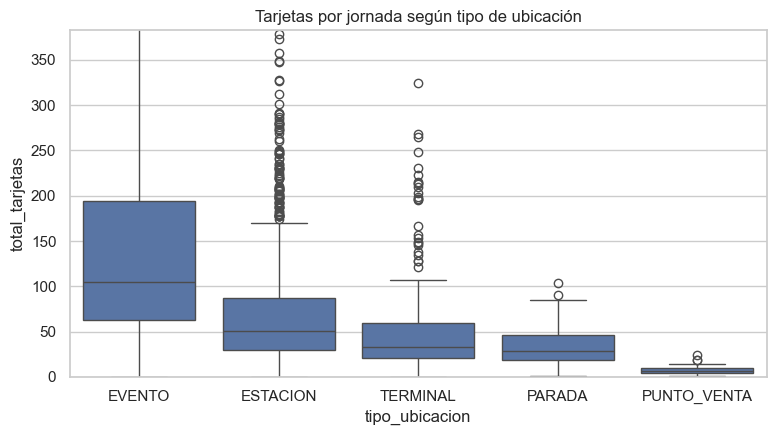

Kruskal-Wallis: H = 327.9, p = 1.04e-69


In [27]:
plt.figure(figsize=(9, 4.5))
sns.boxplot(data=df, x="tipo_ubicacion", y="total_tarjetas", order=por_tipo.index)
plt.ylim(0, df["total_tarjetas"].quantile(0.99)) # recorta el 1 % más alto para ver las cajas
plt.title("Tarjetas por jornada según tipo de ubicación")
plt.show()

# Kruskal-Wallis: ¿las medianas difieren entre tipos? (no asume normalidad)
grupos = [g["total_tarjetas"].values for _, g in df.groupby("tipo_ubicacion", observed=True)]
kw = stats.kruskal(*grupos)
print(f"Kruskal-Wallis: H = {kw.statistic:.1f}, p = {kw.pvalue:.2e}")

### 4.2 Correlación entre variables numéricas
Usamos **Spearman** porque las variables son asimétricas: compara rangos y no se deja arrastrar por valores extremos.

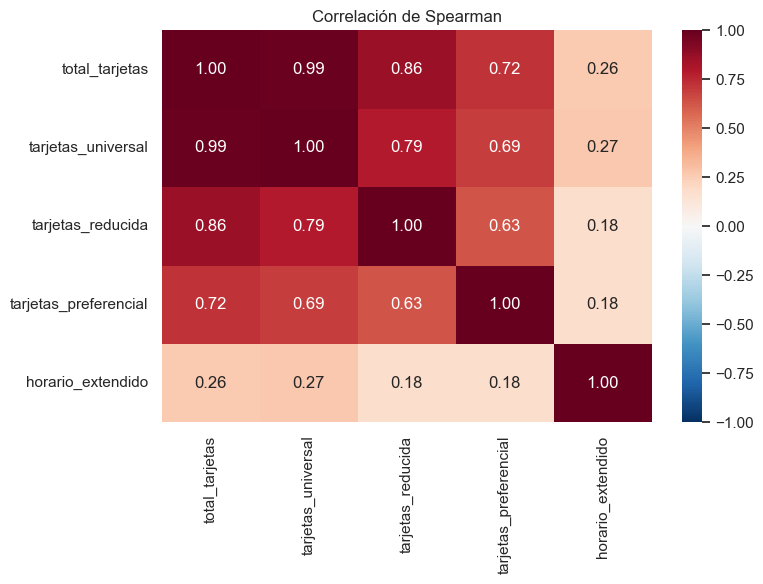

In [28]:
corr = df[numericas].corr(method="spearman") # matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Correlación de Spearman"); plt.tight_layout(); plt.show()

Spearman Universal–Reducida: ρ = 0.79, p = 0.00e+00


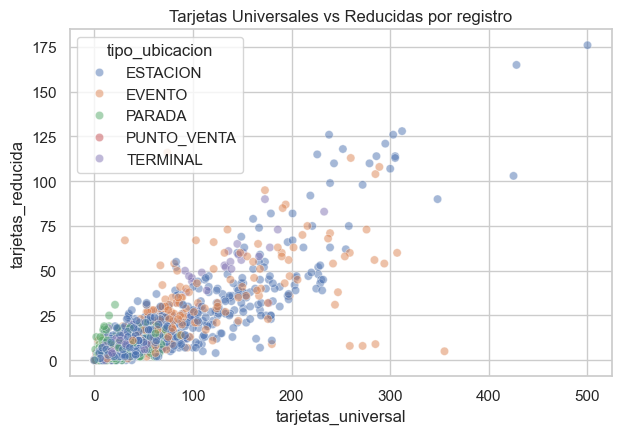

In [29]:
# ¿Donde se entregan más Universales también se entregan más Reducidas?
rho, p = stats.spearmanr(df["tarjetas_universal"], df["tarjetas_reducida"])
print(f"Spearman Universal–Reducida: ρ = {rho:.2f}, p = {p:.2e}")

plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x="tarjetas_universal", y="tarjetas_reducida",
                hue="tipo_ubicacion", alpha=0.5)
plt.title("Tarjetas Universales vs Reducidas por registro"); plt.show()

Los perfiles se mueven juntos (donde hay más demanda, se entregan más de todos), pero **no en la misma proporción en todas partes**, por eso en el Paso 6 analizamos el perfil **por estación**.

In [30]:
import plotly.express as px # gráficos interactivos
from itertools import combinations # genera todos los pares posibles de una lista

# Correlación de Spearman para cada par de perfiles
# Diccionario {nombre de la columna: nombre legible}, para imprimir resultados claros
nombres_perfil = {"tarjetas_universal": "Universal",
                  "tarjetas_reducida": "Reducida",
                  "tarjetas_preferencial": "Preferencial"}

for col_x, col_y in combinations(nombres_perfil, 2): # los 3 pares: U–R, U–P, R–P
    rho, p = stats.spearmanr(df[col_x], df[col_y])
    print(f"Spearman {nombres_perfil[col_x]}–{nombres_perfil[col_y]}: ρ = {rho:.2f}, p = {p:.2e}") 

# Gráfico de dispersión en 3D
fig3d = px.scatter_3d(
    df,
    x="tarjetas_universal", y="tarjetas_reducida", z="tarjetas_preferencial", # los tres ejes
    color="tipo_ubicacion", # color por tipo de ubicación
    color_discrete_map={"ESTACION": "#16324F", "TERMINAL": "#4F7CAC", "EVENTO": "#E07A5F",
                        "PARADA": "#2A9D8F", "PUNTO_VENTA": "#B8B8B8"}, # mismos colores que el dashboard
    opacity=0.6,
    hover_data=["estacion_o_evento", "fecha"], # datos al pasar el mouse
    labels={"tarjetas_universal": "Universal", "tarjetas_reducida": "Reducida",
            "tarjetas_preferencial": "Preferencial", "tipo_ubicacion": "Tipo"},
    title="Tarjetas por perfil en cada registro",
    height=650,
)
fig3d.update_traces(marker=dict(size=3)) # puntos pequeños para que no se tapen

# Guardar como HTML y mostrar
ruta_3d = RAIZ / "reportes" / "perfiles_3d.html"
fig3d.write_html(ruta_3d) # se abre con doble clic en el navegador
print("\nGráfico guardado en:", ruta_3d.relative_to(RAIZ))
fig3d.show()

Spearman Universal–Reducida: ρ = 0.79, p = 0.00e+00
Spearman Universal–Preferencial: ρ = 0.69, p = 4.58e-235
Spearman Reducida–Preferencial: ρ = 0.63, p = 9.35e-186

Gráfico guardado en: reportes\perfiles_3d.html


**Relación entre los perfiles de tarjeta**

Los tres perfiles de tarjeta tienen una **correlación positiva y fuerte** entre sí:

| Par de perfiles | Spearman (ρ) | Fuerza |
|---|---|---|
| Universal – Reducida | 0,79 | Fuerte |
| Universal – Preferencial | 0,69 | Moderada-fuerte |
| Reducida – Preferencial | 0,63 | Moderada-fuerte |

Todos los p-valores son prácticamente cero, así que las relaciones no se deben al azar. Con más de 1.600 registros casi cualquier correlación resulta significativa, por eso lo importante es el **valor de ρ**, no el p-valor.

**Qué muestra el gráfico 3D:**
- La mayoría de los registros se concentra **cerca del origen**: la jornada típica entrega pocas tarjetas de cada perfil. Las **paradas** (verde azulado) están todas en esa zona.
- Desde ahí sale una **nube que sube en diagonal**: cuando un punto entrega muchas tarjetas Universales, también entrega muchas Reducidas y Preferenciales. Los valores más altos corresponden a **estaciones**, en su mayoría de las primeras semanas del registro.
- Los **eventos** (coral) aparecen con muchas tarjetas Universales, lo que coincide con que son el canal más intenso por jornada.

Además, los perfiles se mueven juntos porque dependen de un factor común, el **volumen de demanda** del punto y del día, donde hay más personas, se entregan más tarjetas de todos los perfiles. La correlación con **Preferencial** es algo menor porque es el perfil menos frecuente (3% del total), y muchas jornadas entregan pocas o ninguna.

Sin embargo, que los perfiles se muevan juntos no significa que se entreguen **en la misma proporción** en todos los puntos. Una estación puede entregar muchas tarjetas de todo tipo y, aun así, tener más Reducidas que otra.

### 4.3 ¿Hay días de la semana con más demanda?

In [31]:
# Solo estaciones y terminal: abren todos los días, así la comparación es justa
fijos = df[df["tipo_ubicacion"].isin(["ESTACION", "TERMINAL"])]
fijos.groupby("dia_semana", observed=True)["total_tarjetas"].median().rename("mediana diaria")

dia_semana
Lun   51.00
Mar   49.00
Mié   51.50
Jue   49.50
Vie   49.00
Sáb   46.50
Dom   37.00
Name: mediana diaria, dtype: float64

In [32]:
# Porcentaje de todas las tarjetas que se entrega cada día de la semana
por_dia = (df.groupby("dia_semana", observed=True)["total_tarjetas"].sum()
             / df["total_tarjetas"].sum() * 100).round(1)
print(por_dia)

fin_semana = por_dia[["Sáb", "Dom"]].sum()
print(f"Días laborables: {100 - fin_semana:.1f} %  ·  Fin de semana: {fin_semana:.1f} %")

dia_semana
Lun   15.50
Mar   14.30
Mié   14.90
Jue   14.70
Vie   14.00
Sáb   14.60
Dom   11.90
Name: total_tarjetas, dtype: float64
Días laborables: 73.5 %  ·  Fin de semana: 26.5 %


### 4.4 Horario extendido

In [33]:
# Comparamos jornadas con y sin horario extendido (variable > 0)
(fijos.assign(horario_extendido_activo=fijos["horario_extendido"] > 0)
      .groupby("horario_extendido_activo")["total_tarjetas"].agg(["count", "median"]))

,count,median
horario_extendido_activo,,
False,1110,44.00
True,89,126.00


Los días con horario extendido entregan más tarjetas, pero **eso no prueba que el horario extendido cause más entregas**, probablemente se activa justamente en los días de más demanda. Además, el significado exacto de la variable está por confirmar con la fuente.

## Paso 5. Faltantes, duplicados, inconsistencias y atípicos
### 5.1 Datos faltantes

In [34]:
faltantes = pd.DataFrame({"n": df.isna().sum(),
                          "%": (df.isna().mean() * 100).round(1)})
faltantes[faltantes["n"] > 0] # solo las columnas con algún faltante

,n,%
numero_planilla,211,12.70


Solo falta `numero_planilla` en algunos registros. Es un código de control y **no se usa en el análisis**, así que no requiere tratamiento. Las variables del análisis están completas, por lo que no hace falta imputar.

### 5.2 ¿Hay registros duplicados?

In [35]:
print("Filas idénticas:", df.duplicated().sum())
print("Misma fecha y mismo punto:", df.duplicated(["fecha", "estacion_o_evento"]).sum())

# Miramos algunos casos de fecha + punto repetidos
repetidos = df[df.duplicated(["fecha", "estacion_o_evento"], keep=False)]
repetidos.sort_values(["fecha", "estacion_o_evento"])[
    ["fecha", "estacion_o_evento", "tipo_registro", "total_tarjetas"]].head(6)

Filas idénticas: 0
Misma fecha y mismo punto: 40


,fecha,estacion_o_evento,tipo_registro,total_tarjetas
501,2026-05-22,Quitumbe,PUNTO_VENTA,6
502,2026-05-22,Quitumbe,NORMAL,33
523,2026-05-25,Quitumbe,PUNTO_VENTA,5
524,2026-05-25,Quitumbe,NORMAL,39
530,2026-05-26,Quitumbe,NORMAL,38
531,2026-05-26,Quitumbe,PUNTO_VENTA,4


No hay filas idénticas. Las repeticiones de fecha + punto son **dos planillas distintas del mismo día** (en Quitumbe, una normal y una de punto de venta). **No son duplicados**: se conservan. La clave de un registro no es solo fecha + punto, sino fecha + punto + tipo de registro.

### 5.3 Nombres inconsistentes

In [36]:
# Listamos los nombres en orden alfabético para encontrar variantes de un mismo punto
sorted(df["estacion_o_evento"].unique())

['ADMINISTRACION ZONA QUITUMBE',
 'ALCALDIA',
 'ARCA',
 'BICENTENARIO',
 'BOULEVARD LA CAROLINA',
 'CALDERON',
 'CAPULÍ',
 'CASA SOMOS',
 'CASA SOMOS CARCELEN',
 'CASA SOMOS CHILLOGALO',
 'CASA SOMOS LA BALBINA',
 'CASA SOMOS LA ECUATORIANA',
 'CEAM QUITUMBE',
 'CENTRO GERONTOLOGICO',
 'CENTRO HISTORICO',
 'CENTRO HISTORICO PLAZA GRANDE',
 'CHILLOGALLO',
 'CONCEJO PROVINCIAL',
 'CONFITECA',
 'CONJUNTO LA MENA',
 'CONQUITO',
 'CONSEJO PROVINCIAL',
 'CUMBAYA',
 'Capulí',
 'Casa de la Cultura',
 'Chimbacalle N/S',
 'Colón N/S',
 'Cumandá',
 'DIVINO NIÑO',
 'EJIDO',
 'EL EJIDO',
 'EL INCA',
 'EPN',
 'El Recreo',
 'España',
 'Estación Labrador',
 'Estación Río Coca',
 'Estadio N/S',
 'Eugenio Espejo',
 'Guamaní',
 'HOSPITAL MILITAR',
 'HUECA FEST',
 'IGM',
 'INSTITUTO LIBERTAD',
 'INSTITUTO NUEVA VIDA',
 'IPIALES DEL SUR',
 'Jipijapa',
 'LA BOTA',
 'LA CAROLINA',
 'LA COLINA',
 'LA DELICIA',
 'LA ECUATORIANA',
 'LA FLORESTA -REDONDEL GENARO LARREA',
 'LAS CASAS',
 'LAS CUADRAS',
 'LULUNCOTO

In [37]:
# Variantes encontradas -> nombre estándar
estandar = {
    "EJIDO": "EL EJIDO", "Capulí": "CAPULÍ", "CONCEJO PROVINCIAL": "CONSEJO PROVINCIAL",
    "PMO- UNIVERSIDAD CENTRAL": "PMO UNIVERSIDAD CENTRAL",
    "PMO-UNIVERSIDAD CENTRAL": "PMO UNIVERSIDAD CENTRAL",
    "PMO-LA UNIVERSIDAD CENTRAL": "PMO UNIVERSIDAD CENTRAL",
    "PMO UCE": "PMO UNIVERSIDAD CENTRAL",
    "UCE": "UNIVERSIDAD CENTRAL", "Universidad Central": "UNIVERSIDAD CENTRAL",
    "PMO-NACIONES UNIDAS": "PMO NACIONES UNIDAS", "PMO-LA CAROLINA": "PMO LA CAROLINA",
    "PMO-CONOCOTO": "PMO CONOCOTO", "PMO-COTOCOLLAO": "PMO COTOCOLLAO",
    "PRONACA(MAÑANA)": "PRONACA", "PRONACA(TARDE)": "PRONACA", # mismo evento, dos turnos
    "MERCADO I¥AQUITO": "MERCADO IÑAQUITO", # error de codificación (¥ por Ñ)
    "PMO BASÞLICA": "PMO BASÍLICA", # error de codificación (Þ por Í)
}
antes = df["estacion_o_evento"].nunique()
df["estacion_o_evento"] = df["estacion_o_evento"].replace(estandar) # reemplaza solo las variantes
print(f"Puntos de entrega distintos: {antes} -> {df['estacion_o_evento'].nunique()}")

Puntos de entrega distintos: 103 -> 93


Además de las variantes, los nombres mezclan formatos: unos en MAYÚSCULAS (`CENTRO HISTORICO`), otros con prefijo (`Estación Labrador`), otros con el sentido de la parada (`Colón N/S`) y varios sin tildes. Les damos a todos **un formato uniforme**.

In [38]:
# Reglas de formato
CONECTORES = {"de", "del", "y"} # siempre en minúscula (salvo al inicio)
ARTICULOS = {"la", "las", "los", "el"} # en minúscula solo después de "de"
SIGLAS = {"PMO", "EPN", "IGM", "CEAM", "ARCA", "PJ", "PRONACA"} # se mantienen en mayúsculas
CORRECCIONES_PALABRAS = { # tildes faltantes y errores de escritura
    "Administracion": "Administración", "Alcaldia": "Alcaldía", "Calderon": "Calderón",
    "Carcelen": "Carcelén", "Cumbaya": "Cumbayá", "Gerontologico": "Gerontológico",
    "Historico": "Histórico", "Chillogalo": "Chillogallo", "Conquito": "ConQuito",
}

def formatear_nombre(nombre):
    """Formato uniforme: "CENTRO HISTORICO" → "Centro Histórico", "Colón N/S" → "Colón"."""
    nombre = nombre.strip() # quita espacios al inicio y al final
    nombre = nombre.removeprefix("Estación ") # el tipo ya está en tipo_ubicacion
    nombre = nombre.removesuffix(" N/S") # N/S = ambos sentidos de la parada
    nombre = nombre.replace(" -", " - ").replace("-", " - ") # separa los guiones con espacios
    palabras = []
    for i, palabra in enumerate(nombre.split()): # split() también elimina espacios dobles
        if palabra.upper() in SIGLAS: # sigla → mayúsculas
            palabras.append(palabra.upper())
        elif i > 0 and palabra.lower() in CONECTORES: # "de", "del", "y" → minúscula
            palabras.append(palabra.lower())
        elif i > 0 and palabra.lower() in ARTICULOS and palabras[-1] == "de": # "de la" → minúscula
            palabras.append(palabra.lower())
        else: # resto → Primera letra en mayúscula
            palabra = palabra.capitalize()
            palabras.append(CORRECCIONES_PALABRAS.get(palabra, palabra)) # agrega tildes faltantes
    return " ".join(palabras)

df["estacion_o_evento"] = df["estacion_o_evento"].map(formatear_nombre) # se aplica a cada nombre
sorted(df["estacion_o_evento"].unique())

['ARCA',
 'Administración Zona Quitumbe',
 'Alcaldía',
 'Bicentenario',
 'Boulevard La Carolina',
 'CEAM Quitumbe',
 'Calderón',
 'Capulí',
 'Casa Somos',
 'Casa Somos Carcelén',
 'Casa Somos Chillogallo',
 'Casa Somos La Balbina',
 'Casa Somos La Ecuatoriana',
 'Casa de la Cultura',
 'Centro Gerontológico',
 'Centro Histórico',
 'Centro Histórico Plaza Grande',
 'Chillogallo',
 'Chimbacalle',
 'Colón',
 'ConQuito',
 'Confiteca',
 'Conjunto La Mena',
 'Consejo Provincial',
 'Cumandá',
 'Cumbayá',
 'Divino Niño',
 'EPN',
 'El Ejido',
 'El Inca',
 'El Recreo',
 'España',
 'Estadio',
 'Eugenio Espejo',
 'Guamaní',
 'Hospital Militar',
 'Hueca Fest',
 'IGM',
 'Instituto Libertad',
 'Instituto Nueva Vida',
 'Ipiales del Sur',
 'Jipijapa',
 'La Bota',
 'La Carolina',
 'La Colina',
 'La Delicia',
 'La Ecuatoriana',
 'La Floresta - Redondel Genaro Larrea',
 'Labrador',
 'Las Casas',
 'Las Cuadras',
 'Luluncoto',
 'Magdalena',
 'Martha Bucaram',
 'Mercado Central',
 'Mercado Iñaquito',
 'Mercad

### 5.4 Corredor asignado a los eventos

In [39]:
pd.crosstab(df["tipo_ubicacion"], df["corredor"]) # registros por tipo y corredor

corredor,Ecovía Norte,Sur Oriental,Trole Norte,Trole Sur
tipo_ubicacion,,,,
ESTACION,200,400,200,199
EVENTO,0,0,0,195
PARADA,46,0,67,116
PUNTO_VENTA,0,0,0,40
TERMINAL,0,0,0,200


**Todos los eventos figuran en el corredor Trole Sur**, incluso los hechos en Cumbayá, Calderón o La Carolina. El corredor de un evento es una **asignación administrativa**, no su ubicación. **Tratamiento:** las comparaciones entre corredores se hacen **sin eventos**.

### 5.5 Atípicos
Aplicamos la regla de 1,5·IQR **dentro de cada tipo de ubicación**, porque una estación y un punto de venta tienen escalas muy distintas.

In [40]:
def atipico_iqr(serie):
    """True si el valor supera Q3 + 1,5·IQR de su propio grupo."""
    q1, q3 = serie.quantile([0.25, 0.75]) # primer y tercer cuartil
    return serie > q3 + 1.5 * (q3 - q1) # límite superior de la regla

df["atipico"] = (df.groupby("tipo_ubicacion", observed=True)["total_tarjetas"]
                   .transform(atipico_iqr)) # transform devuelve un valor por fila
print(df.groupby("tipo_ubicacion", observed=True)["atipico"].sum().rename("atípicos"))
df[df["atipico"]].nlargest(8, "total_tarjetas")[
    ["fecha", "estacion_o_evento", "tipo_ubicacion", "total_tarjetas"]]

tipo_ubicacion
ESTACION       102
EVENTO           2
PARADA           2
PUNTO_VENTA      3
TERMINAL        26
Name: atípicos, dtype: int64


,fecha,estacion_o_evento,tipo_ubicacion,total_tarjetas
162,2026-04-01,El Recreo,ESTACION,702
150,2026-03-30,El Recreo,ESTACION,616
156,2026-03-31,El Recreo,ESTACION,543
90,2026-03-20,El Recreo,ESTACION,466
108,2026-03-23,El Recreo,ESTACION,456
120,2026-03-25,El Recreo,ESTACION,446
114,2026-03-24,El Recreo,ESTACION,441
126,2026-03-26,El Recreo,ESTACION,436


In [41]:
# ¿En qué meses ocurren los atípicos?
df[df["atipico"]].groupby("mes").size().rename("atípicos por mes")

mes
2026-03    83
2026-04    42
2026-05     3
2026-06     1
2026-07     4
2026-08     2
Name: atípicos por mes, dtype: int64

Los atípicos se concentran en **marzo y abril**, las primeras semanas del lanzamiento. Son **días reales de alta demanda**, no errores: **se conservan** y quedan marcados en la columna `atipico`. Para que no distorsionen, las comparaciones usan medianas.

**Resumen de decisiones de calidad**

| Problema | Decisión |
|---|---|
| Columna del tipo de registro sin nombre | Renombrada a `tipo_registro` |
| Faltan `sistema` y `tipo_ubicacion` | Derivadas y validadas contra otra hoja (0 diferencias) |
| `total_dinero` sin definición clara | Excluida del análisis |
| Distribución de 27.000 tarjetas al municipio | Excluida (no es demanda del público) |
| 3 columnas constantes (`valor_tarifa_*`) | Eliminadas |
| `valor_tarifa_*` parecen precios | No se usan: solo identifican el perfil |
| `numero_planilla` con faltantes | Sin tratamiento (no se usa) |
| Fecha + punto repetidos | Se conservan (son planillas distintas) |
| 17 variantes de nombres y formatos mezclados | Unificadas y con formato uniforme |
| Eventos asignados a Trole Sur | Comparaciones por corredor sin eventos |
| Atípicos del lanzamiento | Se conservan y se marcan; se usan medianas |

## Paso 6. Segmentación
### 6.1 Evolución desde el lanzamiento

mes
2026-03   169.00
2026-04   104.50
2026-05    47.00
2026-06    30.00
2026-07    35.00
2026-08    35.50
2026-09    48.50
Name: mediana diaria por estación, dtype: float64


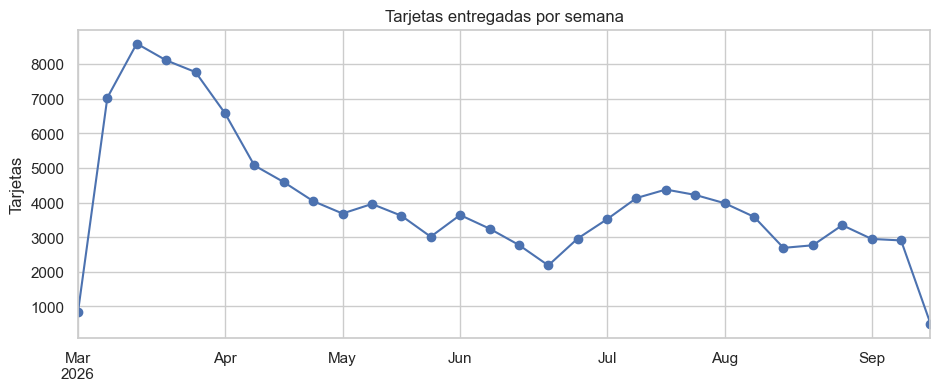

In [42]:
# Mediana diaria por estación/terminal en cada mes
fijos = df[df["tipo_ubicacion"].isin(["ESTACION", "TERMINAL"])] # se recalcula tras la limpieza
evolucion = fijos.groupby("mes")["total_tarjetas"].median().rename("mediana diaria por estación")
print(evolucion)

# Total semanal de tarjetas en todos los canales
semanal = df.groupby("semana")["total_tarjetas"].sum()
semanal.plot(figsize=(11, 4), marker="o", title="Tarjetas entregadas por semana")
plt.ylabel("Tarjetas"); plt.xlabel(""); plt.show()

In [43]:
caida = (1 - evolucion.min() / evolucion.iloc[0]) * 100
print(f"Caída desde marzo hasta el mes más bajo: {caida:.0f} %")

Caída desde marzo hasta el mes más bajo: 82 %


### 6.2 ¿Qué puntos concentran la entrega?

In [44]:
ranking = (df.groupby(["estacion_o_evento", "tipo_ubicacion"], observed=True)
             .agg(tarjetas=("total_tarjetas", "sum"))
             .sort_values("tarjetas", ascending=False))
ranking["%_tarjetas"] = ranking["tarjetas"] / ranking["tarjetas"].sum() * 100
ranking["%_acumulado"] = ranking["%_tarjetas"].cumsum() # curva de concentración (Pareto)
ranking.head(10)

,,tarjetas,%_tarjetas,%_acumulado
estacion_o_evento,tipo_ubicacion,,,
El Recreo,ESTACION,25594,21.20,21.20
Labrador,ESTACION,17094,14.16,35.36
Río Coca,ESTACION,14129,11.70,47.06
Quitumbe,TERMINAL,11175,9.26,56.31
Playón de la Marín,ESTACION,10174,8.43,64.74
Guamaní,ESTACION,8420,6.97,71.71
Plaza Chica,EVENTO,2806,2.32,74.04
Plaza Grande,EVENTO,2560,2.12,76.16
Centro Histórico,EVENTO,2050,1.70,77.85


### 6.3 ¿Qué canal entrega más tarjetas por jornada?

In [45]:
canales = por_tipo[["mediana", "%_del_total"]].rename(
    columns={"mediana": "tarjetas_por_jornada"}) # del Paso 4.1
canales.sort_values("tarjetas_por_jornada", ascending=False)

,tarjetas_por_jornada,%_del_total
tipo_ubicacion,,
EVENTO,105.00,21.53
ESTACION,51.00,62.46
TERMINAL,33.00,9.26
PARADA,29.00,6.52
PUNTO_VENTA,6.00,0.23


Un **evento** entrega el doble de tarjetas por jornada que una estación, es el canal más intenso, aunque ocurre solo algunos días. Las **estaciones** son el canal más constante y concentran la mayor parte del total.

### 6.4 Perfil de tarjeta por estación
Es el núcleo de la pregunta: ¿cada estación necesita la misma mezcla de tarjetas? Usamos estaciones y terminal, que abren todos los días.

In [46]:
por_estacion = fijos.groupby("estacion_o_evento")[perfiles].sum() # tarjetas de cada perfil
por_estacion["total"] = por_estacion[perfiles].sum(axis=1)
por_estacion = por_estacion.sort_values("total", ascending=False)

# Mezcla de perfiles en cada estación (%)
mezcla_estacion = (por_estacion[perfiles].div(por_estacion["total"], axis=0) * 100).round(1)
print(mezcla_estacion.sort_values("tarjetas_reducida", ascending=False))

# ¿Qué parte de TODAS las tarjetas de cada perfil entrega cada estación?
reparto = (por_estacion[perfiles] / por_estacion[perfiles].sum() * 100).round(1)
print("\n% del total de cada perfil que entrega cada estación:")
print(reparto)

                    tarjetas_universal  tarjetas_reducida  \
estacion_o_evento                                           
El Recreo                        71.50              24.70   
Quitumbe                         72.50              24.00   
Guamaní                          75.90              21.50   
Labrador                         78.80              17.70   
Río Coca                         80.60              16.20   
Playón de la Marín               83.40              13.00   

                    tarjetas_preferencial  
estacion_o_evento                          
El Recreo                            3.80  
Quitumbe                             3.50  
Guamaní                              2.60  
Labrador                             3.50  
Río Coca                             3.10  
Playón de la Marín                   3.60  

% del total de cada perfil que entrega cada estación:
                    tarjetas_universal  tarjetas_reducida  \
estacion_o_evento                          

Chi-cuadrado = 1,015.7, gl = 10, p = 7.72e-212, V de Cramér = 0.08


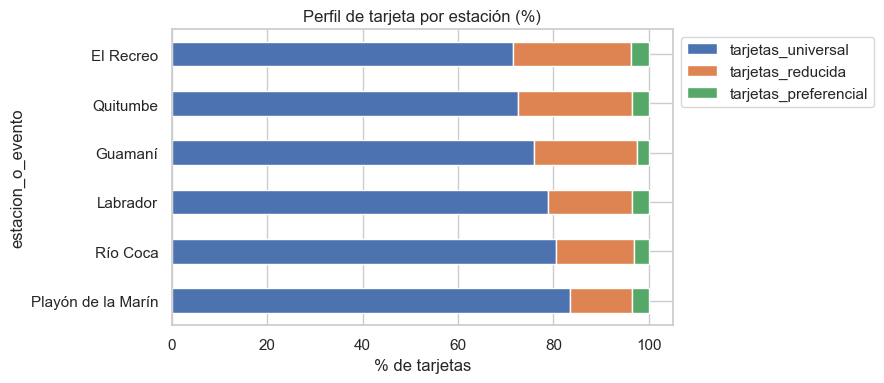

In [47]:
# Chi-cuadrado: ¿la mezcla de perfiles depende de la estación?
chi2_e, p_e, gl_e, _ = stats.chi2_contingency(por_estacion[perfiles].values)
v_e = np.sqrt(chi2_e / (por_estacion[perfiles].values.sum() * (len(perfiles) - 1))) # V de Cramér
print(f"Chi-cuadrado = {chi2_e:,.1f}, gl = {gl_e}, p = {p_e:.2e}, V de Cramér = {v_e:.2f}")

mezcla_estacion.sort_values("tarjetas_reducida").plot.barh(
    stacked=True, figsize=(9, 4), title="Perfil de tarjeta por estación (%)")
plt.xlabel("% de tarjetas"); plt.legend(bbox_to_anchor=(1, 1)); plt.tight_layout(); plt.show()

La proporción de tarjetas **Reducidas** va del **13%** en Playón de la Marín al **25%** en El Recreo, y **El Recreo entrega el 36% de todas las Reducidas** de las estaciones. La diferencia entre estaciones es significativa, aunque su tamaño es pequeño. Para el inventario sí importa, un mismo lote para todas las estaciones dejaría a El Recreo y Quitumbe cortas de T.Reducidas y a Playón de la Marín con sobrante.

### 6.5 Perfiles de tarjeta por corredor (sin eventos)

              tarjetas_universal  tarjetas_reducida  tarjetas_preferencial
corredor                                                                  
Ecovía Norte               81.20              15.70                   3.10
Sur Oriental               80.00              16.80                   3.20
Trole Norte                78.80              17.80                   3.40
Trole Sur                  71.40              25.00                   3.70

Chi-cuadrado = 1,010.0, gl = 6, p = 6.15e-215, V de Cramér = 0.07


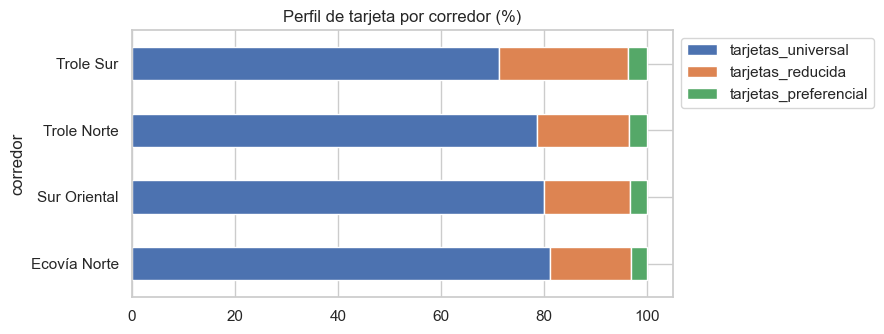

In [48]:
sin_eventos = df[df["tipo_ubicacion"] != "EVENTO"] # ver decisión del Paso 5.4
por_corredor = sin_eventos.groupby("corredor", observed=True)[perfiles].sum()
pct = (por_corredor.div(por_corredor.sum(axis=1), axis=0) * 100).round(1)
print(pct)

# Chi-cuadrado: ¿la mezcla de perfiles depende del corredor?
chi2, p, gl, _ = stats.chi2_contingency(por_corredor.values)
v = np.sqrt(chi2 / (por_corredor.values.sum() * (min(por_corredor.shape) - 1))) # V de Cramér
print(f"\nChi-cuadrado = {chi2:,.1f}, gl = {gl}, p = {p:.2e}, V de Cramér = {v:.2f}")

pct.plot.barh(stacked=True, figsize=(9, 3.5), title="Perfil de tarjeta por corredor (%)")
plt.legend(bbox_to_anchor=(1, 1)); plt.tight_layout(); plt.show()

La mezcla de perfiles **sí depende del corredor** (p muy pequeño): el Trole Sur entrega más tarjetas **Reducidas**. Pero la V de Cramér es baja, la diferencia es real y **pequeña**. Con tantas tarjetas, casi cualquier diferencia resulta significativa; por eso siempre miramos también el tamaño del efecto.

### 6.6 Día de la semana × corredor

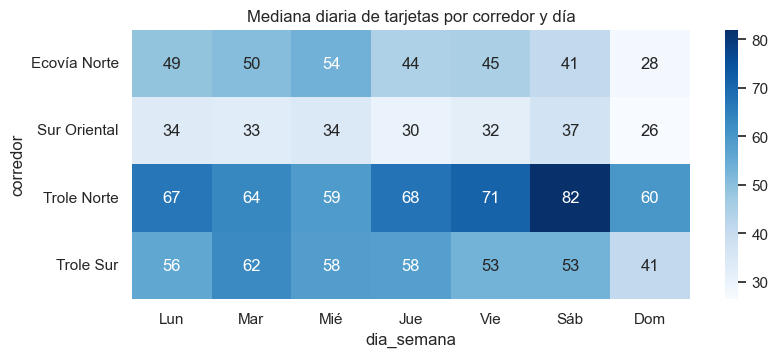

In [49]:
mapa_calor = fijos.pivot_table(values="total_tarjetas", index="corredor", columns="dia_semana",
                               aggfunc="median", observed=True)
plt.figure(figsize=(9, 3.5))
sns.heatmap(mapa_calor, annot=True, fmt=".0f", cmap="Blues")
plt.title("Mediana diaria de tarjetas por corredor y día"); plt.show()

El **domingo** es el día más bajo en Ecovía Norte, Sur Oriental y Trole Sur. El **Trole Norte** (estación Labrador) es la excepción: su día más alto es el **sábado**, lo que sugiere reforzar esa estación los fines de semana.

### 6.7 Vista geográfica de los puntos con coordenadas

In [50]:
coords = pd.read_csv(RUTA_ESTACIONES) # coordenadas en bruto
coords.head()

,Tipo,Nombre,Latitud,Longitud,Coordenadas_GMS
0,Terminal / Estacion Multimodal,Terminal Terrestre Quitumbe,-0.30,-78.56,0°17′44″S 78°33′24″O
1,Terminal / Estacion Multimodal,Estacion Multimodal El Labrador,-0.15,-78.49,0°09′18″S 78°29′12″O
2,Terminal / Estacion Multimodal,Terminal Sur – El Recreo,-0.25,-78.52,0°15′09″S 78°31′17″O
3,Terminal / Estacion Multimodal,Terminal Interparroquial Rio Coca,-0.16,-78.47,0°09′50″S 78°28′22″O
4,Terminal / Estacion Multimodal,Terminal Microregional Playon de la Marin,-0.23,-78.51,0°13′48″S 78°30′24″O


Puntos con coordenadas: 14 - cubren el 83 % de las tarjetas


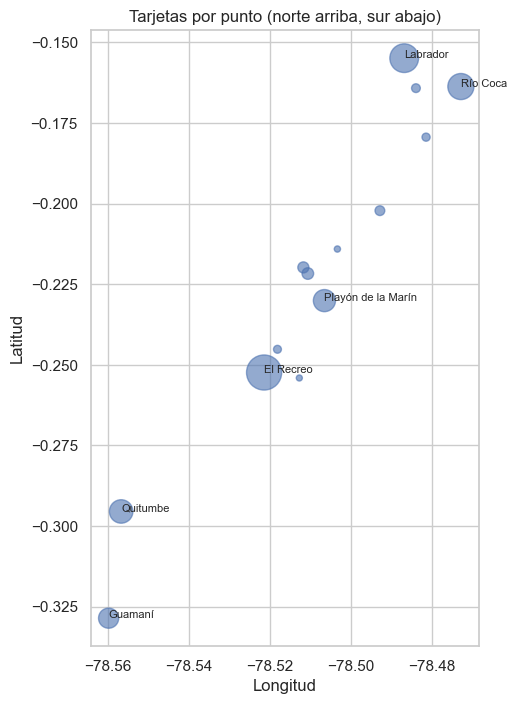

In [51]:
# Los nombres del archivo de coordenadas no coinciden con los del Excel: los emparejamos
mapa_nombres = {
    "Terminal Terrestre Quitumbe": "Quitumbe", "Estacion Multimodal El Labrador": "Labrador",
    "Terminal Sur – El Recreo": "El Recreo", "Terminal Interparroquial Rio Coca": "Río Coca",
    "Terminal Microregional Playon de la Marin": "Playón de la Marín",
    "Terminal Sur Ecovia – Guamani": "Guamaní", "Parada Espana (Ecovia)": "España",
    "Parada Jipijapa (Metro / Ecovia)": "Jipijapa", "Parada Chimbacalle (Trolebus)": "Chimbacalle",
    "Parada Colon (Trolebus / Ecovia)": "Colón", "Parada Estadio (Ecovia)": "Estadio",
    "Parada La Colina (Ecovia)": "La Colina", "Parada Plaza Chica (Trolebus)": "Plaza Chica",
    "Parada Plaza Grande (Trolebus)": "Plaza Grande",
}
coords["estacion_o_evento"] = coords["Nombre"].map(mapa_nombres)

por_punto = (df.groupby("estacion_o_evento")["total_tarjetas"].sum() # un total por punto
               .rename("tarjetas").reset_index())
por_punto["%_tarjetas"] = por_punto["tarjetas"] / por_punto["tarjetas"].sum() * 100
geo = por_punto.merge(coords, on="estacion_o_evento", how="inner") # solo puntos con coordenadas
print(f"Puntos con coordenadas: {len(geo)} - cubren el {geo['%_tarjetas'].sum():.0f} % de las tarjetas")

plt.figure(figsize=(5, 8))
plt.scatter(geo["Longitud"], geo["Latitud"], s=geo["tarjetas"] / 40, alpha=0.6) # tamaño = tarjetas
for _, fila in geo.nlargest(6, "tarjetas").iterrows():
    plt.annotate(fila["estacion_o_evento"], (fila["Longitud"], fila["Latitud"]), fontsize=8)
plt.title("Tarjetas por punto (norte arriba, sur abajo)")
plt.xlabel("Longitud"); plt.ylabel("Latitud"); plt.show()

Quito es una ciudad alargada de norte a sur. Las burbujas más grandes están en el **sur** (El Recreo, Quitumbe, Guamaní, Playón de la Marín) y en el **norte** (Labrador, Río Coca), es decir, en los **extremos de los corredores**, donde se hacen los trasbordos. El mapa interactivo está en la sección 6.8 y en el dashboard.

### 6.8 Mapa inclinable de burbujas
Cada punto de entrega es una **burbuja** cuyo **tamaño** indica las tarjetas entregadas y cuyo **color** indica el tipo de ubicación. El tamaño usa la raíz cuadrada de las tarjetas, para que el **área** de cada burbuja sea proporcional al valor.

In [52]:
import pydeck as pdk                              # mapas interactivos que se pueden inclinar y girar (deck.gl)
import webbrowser                                 # abre el mapa en el navegador

# --- 1. Datos por punto, unidos con sus coordenadas (usa `coords` de las celdas anteriores) ---
por_punto_3d = (df.groupby("estacion_o_evento")
                  .agg(tarjetas=("total_tarjetas", "sum"),
                       universal=("tarjetas_universal", "sum"),
                       reducida=("tarjetas_reducida", "sum"),
                       preferencial=("tarjetas_preferencial", "sum"),
                       tipo=("tipo_ubicacion", lambda s: s.mode().iloc[0]))
                  .reset_index()
                  .merge(coords, on="estacion_o_evento", how="inner"))
por_punto_3d["pct"] = (por_punto_3d["tarjetas"] / df["total_tarjetas"].sum() * 100).round(1)

# Color de cada burbuja según el tipo de ubicación, en formato [rojo, verde, azul, transparencia]
color_rgb = {"ESTACION": [22, 50, 79, 170], "TERMINAL": [79, 124, 172, 170],
             "EVENTO": [224, 122, 95, 170], "PARADA": [42, 157, 143, 170]}
por_punto_3d["tipo"] = por_punto_3d["tipo"].astype(str)          # texto simple (no categoría)
por_punto_3d["color"] = por_punto_3d["tipo"].map(color_rgb)

# Radio de cada burbuja en METROS, proporcional a la raíz de las tarjetas (así el ÁREA ∝ tarjetas)
maximo_3d = por_punto_3d["tarjetas"].max()
por_punto_3d["radio_m"] = 150 + 1100 * np.sqrt(por_punto_3d["tarjetas"] / maximo_3d)

# --- 2. Capa de burbujas ---
burbujas = pdk.Layer(
    "ScatterplotLayer", #ColumnLayer, TextLayer
    data=por_punto_3d,
    get_position=["Longitud", "Latitud"],         # posición (primero longitud, luego latitud)
    get_radius="radio_m",                         # tamaño de la burbuja en metros
    get_fill_color="color",                       # relleno según el tipo de ubicación
    stroked=True,                                 # borde para separar burbujas superpuestas
    get_line_color=[255, 255, 255, 230],          # borde blanco
    line_width_min_pixels=1.5,
    pickable=True,                                # permite ver la ficha al pasar el mouse
    auto_highlight=True,                          # resalta la burbuja bajo el mouse
)

# --- 3. Vista inicial: inclinada y girada (se puede cambiar con el mouse) ---
vista = pdk.ViewState(latitude=-0.22, longitude=-78.51, zoom=11.3,
                      pitch=45,                   # inclinación (0 = vista desde arriba)
                      bearing=-20)                # giro del mapa en grados

# Ficha al pasar el mouse sobre una burbuja
ficha = {"html": "<b>{Nombre}</b><br/>Tarjetas: {tarjetas} ({pct} % del total)<br/>"
                 "Universal: {universal} · Reducida: {reducida} · Preferencial: {preferencial}",
         "style": {"backgroundColor": "white", "color": "#1B2430", "fontSize": "12px"}}

mapa_3d = pdk.Deck(layers=[burbujas], initial_view_state=vista, tooltip=ficha,
                   map_provider="carto", map_style=pdk.map_styles.LIGHT)   # fondo claro de CARTO

# --- 4. Guardar como HTML y abrirlo en el navegador ---
ruta_3d_mapa = RAIZ / "reportes" / "mapa_tarjetas_3d.html"
mapa_3d.to_html(str(ruta_3d_mapa), open_browser=False)
print("Mapa guardado en:", ruta_3d_mapa.relative_to(RAIZ))
webbrowser.open_new(ruta_3d_mapa.resolve().as_uri())

Mapa guardado en: reportes\mapa_tarjetas_3d.html


True

### 6.9 Mapa interactivo de burbujas (HTML)
El gráfico anterior es estático. Ahora construimos un **mapa interactivo** sobre calles reales de Quito con **Folium**: cada burbuja es un punto de entrega, su tamaño indica las tarjetas y, al hacer clic, se abre una **ficha de información**. El mapa se guarda como `reportes/mapa_tarjetas.html` y se abre con doble clic en cualquier navegador.

In [53]:
import folium # mapas interactivos basados en Leaflet
from branca.element import Element # para agregar la leyenda en HTML

# Coordenadas: emparejar el nombre oficial con el nombre del punto en el Excel
mapa_nombres = {
    "Terminal Terrestre Quitumbe": "Quitumbe",
    "Estacion Multimodal El Labrador": "Labrador",
    "Terminal Sur – El Recreo": "El Recreo",
    "Terminal Interparroquial Rio Coca": "Río Coca",
    "Terminal Microregional Playon de la Marin": "Playón de la Marín",
    "Terminal Sur Ecovia – Guamani": "Guamaní",
    "Parada Espana (Ecovia)": "España",
    "Parada Jipijapa (Metro / Ecovia)": "Jipijapa",
    "Parada Chimbacalle (Trolebus)": "Chimbacalle",
    "Parada Colon (Trolebus / Ecovia)": "Colón",
    "Parada Estadio (Ecovia)": "Estadio",
    "Parada La Colina (Ecovia)": "La Colina",
    "Parada Plaza Chica (Trolebus)": "Plaza Chica",
    "Parada Plaza Grande (Trolebus)": "Plaza Grande",
}
coords = pd.read_csv(RUTA_ESTACIONES) # coordenadas en bruto
coords["estacion_o_evento"] = coords["Nombre"].map(mapa_nombres) # nombre con el que aparece en el Excel

# Resumen por punto con los datos de la ficha
ficha_punto = (df.groupby("estacion_o_evento")
                 .agg(tarjetas=("total_tarjetas", "sum"), # total de tarjetas
                      universal=("tarjetas_universal", "sum"), # por perfil
                      reducida=("tarjetas_reducida", "sum"),
                      preferencial=("tarjetas_preferencial", "sum"),
                      jornadas=("fecha", "nunique"), # días con entregas
                      tipo=("tipo_ubicacion", lambda s: s.mode().iloc[0])) # tipo más frecuente
                 .reset_index())
ficha_punto["%_tarjetas"] = ficha_punto["tarjetas"] / ficha_punto["tarjetas"].sum() * 100
ficha_punto["tarjetas_por_jornada"] = ficha_punto["tarjetas"] / ficha_punto["jornadas"]

# Unir con las coordenadas (solo los puntos que las tienen)
geo_mapa = ficha_punto.merge(coords, on="estacion_o_evento", how="inner")
print(f"Puntos en el mapa: {len(geo_mapa)} · cubren el {geo_mapa['%_tarjetas'].sum():.0f} % de las tarjetas")

# Nombre legible y color fijo para cada tipo de ubicación
nombre_tipo = {"ESTACION": "Estación", "TERMINAL": "Terminal", "EVENTO": "Evento", "PARADA": "Parada"}
color_tipo = {"ESTACION": "#16324F", "TERMINAL": "#4F7CAC", "EVENTO": "#E07A5F", "PARADA": "#2A9D8F"}

# 4. Mapa base centrado en Quito, con varios fondos para elegir
mapa = folium.Map(location=[-0.22, -78.51], # centro de Quito
                  zoom_start=12, # nivel de acercamiento inicial
                  tiles=None) # sin fondo: los agregamos abajo

base_esri = "https://server.arcgisonline.com/ArcGIS/rest/services/{}/MapServer/tile/{{z}}/{{y}}/{{x}}"

# Fondos disponibles (todos de Esri: gratis, sin clave y funcionan al abrir el HTML como archivo).
# El PRIMERO que se agrega es el que aparece al abrir el mapa.
fondos = {
    "Gris claro (recomendado)": "Canvas/World_Light_Gray_Base",   # limpio: resalta las burbujas
    "Gris oscuro": "Canvas/World_Dark_Gray_Base",                 # elegante, ideal para proyectar
    "Topográfico": "World_Topo_Map",                              # relieve y calles
    "Satélite": "World_Imagery",                                  # imagen aérea real
    "Calles": "World_Street_Map",                                 # el fondo anterior
}
for nombre, servicio in fondos.items():
    folium.TileLayer(tiles=base_esri.format(servicio), attr="Tiles © Esri",
                     name=nombre, max_zoom=16).add_to(mapa)

# Capa de nombres de calles y barrios encima del fondo gris claro (se puede apagar)
folium.TileLayer(tiles=base_esri.format("Canvas/World_Light_Gray_Base"),
                 attr="Tiles © Esri", name="Nombres de lugares",
                 overlay=True, max_zoom=16).add_to(mapa)

# Una burbuja por punto de entrega
maximo = geo_mapa["tarjetas"].max() # para escalar el tamaño de las burbujas
for _, fila in geo_mapa.iterrows():
    # Radio proporcional a la raíz de las tarjetas: así el ÁREA es proporcional al valor
    radio = 6 + 34 * np.sqrt(fila["tarjetas"] / maximo)

    # Ficha de información
    ficha = f"""
    <b>{fila['Nombre']}</b><br>
    Tipo: {nombre_tipo[fila['tipo']]}<br>
    Tarjetas: {fila['tarjetas']:,.0f} ({fila['%_tarjetas']:.1f} % del total)<br>
    Universal: {fila['universal']:,.0f} · Reducida: {fila['reducida']:,.0f} ·
    Preferencial: {fila['preferencial']:,.0f}<br>
    Días con entregas: {fila['jornadas']}<br>
    Tarjetas por jornada: {fila['tarjetas_por_jornada']:.0f}
    """
    folium.CircleMarker(
        location=[fila["Latitud"], fila["Longitud"]], # posición del punto
        radius=radio, # tamaño de la burbuja
        color=color_tipo[fila["tipo"]], # color del borde
        fill=True, fill_color=color_tipo[fila["tipo"]], fill_opacity=0.55,
        popup=folium.Popup(ficha, max_width=280), # ficha al hacer clic
        tooltip=f"{fila['estacion_o_evento']}: {fila['tarjetas']:,.0f} tarjetas",  # texto al pasar el mouse
    ).add_to(mapa)

# Leyenda de colores (HTML fijo en la esquina inferior izquierda)
filas_leyenda = "".join(
    f'<div><span style="display:inline-block;width:12px;height:12px;border-radius:50%;'
    f'background:{color_tipo[t]};margin-right:6px"></span>{nombre_tipo[t]}</div>'
    for t in geo_mapa["tipo"].unique())
leyenda = f"""
<div style="position:fixed;bottom:25px;left:25px;z-index:9999;background:white;padding:8px 12px;
            border-radius:6px;box-shadow:0 1px 4px rgba(0,0,0,.3);font-size:13px">
  <b>Tipo de ubicación</b>{filas_leyenda}
  <div style="margin-top:4px;color:#555">Tamaño = tarjetas entregadas</div>
</div>"""
mapa.get_root().html.add_child(Element(leyenda))

# 7. Guardar el mapa como HTML y abrirlo en una ventana aparte
import webbrowser                                   # abre archivos en el navegador

ruta_mapa = RAIZ / "reportes" / "mapa_tarjetas.html"
mapa.save(ruta_mapa)                                # guarda el mapa interactivo en reportes/
print("Mapa guardado en:", ruta_mapa.relative_to(RAIZ))

# Abre el mapa en una ventana nueva del navegador (ahí sí se ven las calles)
webbrowser.open_new(ruta_mapa.resolve().as_uri())
print("Mapa abierto en una ventana nueva del navegador.")

Puntos en el mapa: 14 · cubren el 83 % de las tarjetas
Mapa guardado en: reportes\mapa_tarjetas.html
Mapa abierto en una ventana nueva del navegador.


Intentamos mostrar el mapa de OpenStreetMap dentro del notebook, pero VS Code bloquea las imágenes del mapa base, y OpenStreetMap las rechaza cuando el mapa se abre como archivo local. Por eso, en el notebook usamos el fondo de Esri y abrimos el mapa en una ventana aparte. En el dashboard sí se integra, porque construye su propio mapa y lo muestra en el navegador desde una dirección web local.

Dentro de VS Code, con el OpenStreetMap se ven las burbujas y la leyenda, pero **no las calles**: su visor de notebooks bloquea las imágenes externas del mapa base. Así que se decidió exportar el mapa completo a `reportes/mapa_tarjetas.html`.

## Paso 7. Hallazgos, decisiones y limitaciones

In [54]:
# Cifras clave que se citan en los hallazgos (se calculan, no se escriben a mano)
top6 = ranking.head(6)["%_tarjetas"].sum()
print(f"1. Mediana diaria por estación: marzo {evolucion.iloc[0]:.0f} → mínimo {evolucion.min():.0f} "
      f"({evolucion.idxmin()}) → septiembre {evolucion.iloc[-1]:.0f}")
print(f"2. Las 6 estaciones principales concentran el {top6:.0f} % · El Recreo el {ranking['%_tarjetas'].iloc[0]:.0f} %")
print(f"3. % Reducida por estación: de {mezcla_estacion['tarjetas_reducida'].min():.0f} % a "
      f"{mezcla_estacion['tarjetas_reducida'].max():.0f} % · El Recreo entrega el "
      f"{reparto.loc['El Recreo', 'tarjetas_reducida']:.0f} % de las Reducidas de las estaciones")
print(f"4. Mezcla de perfiles: {(mezcla / mezcla.sum() * 100).round(0).to_dict()}")
print(f"5. Tarjetas por jornada: evento {canales.loc['EVENTO', 'tarjetas_por_jornada']:.0f} vs "
      f"estación {canales.loc['ESTACION', 'tarjetas_por_jornada']:.0f}")
print(f"6. Mediana del domingo: {fijos.groupby('dia_semana', observed=True)['total_tarjetas'].median()['Dom']:.0f}")

1. Mediana diaria por estación: marzo 169 → mínimo 30 (2026-06) → septiembre 48
2. Las 6 estaciones principales concentran el 72 % · El Recreo el 21 %
3. % Reducida por estación: de 13 % a 25 % · El Recreo entrega el 36 % de las Reducidas de las estaciones
4. Mezcla de perfiles: {'tarjetas_universal': 76.0, 'tarjetas_reducida': 21.0, 'tarjetas_preferencial': 3.0}
5. Tarjetas por jornada: evento 105 vs estación 51
6. Mediana del domingo: 37


**Respuesta a la pregunta:** la entrega de tarjetas se concentra en **seis estaciones en los extremos norte y sur de los corredores**, y cada una necesita una **mezcla distinta de perfiles**: las estaciones del sur (El Recreo y Quitumbe) entregan muchas más tarjetas Reducidas. La demanda cayó con fuerza después del lanzamiento, los eventos son el canal más intenso por jornada y el domingo es el día más bajo. Por eso el inventario debe repartirse **por estación y por perfil**, no en lotes iguales.

**Hallazgos**
1. **La demanda cayó cerca de un 80% después del lanzamiento:** la mediana diaria por estación pasó de 169 tarjetas en marzo a 30 en junio, con un leve repunte en septiembre (48).
2. **La entrega está muy concentrada:** 6 estaciones reúnen el 72% de las tarjetas; solo El Recreo, el 21%.
3. **Cada estación entrega una mezcla distinta de perfiles:** las tarjetas Reducidas van del 13% (Playón de la Marín) al 25% (El Recreo), y El Recreo entrega el 36% de todas las Reducidas de las estaciones.
4. **El 76% de las tarjetas son Universales**, el 21% Reducidas y el 3% Preferenciales. Por corredor, el Trole Sur entrega más Reducidas (25% frente a 16-18%).
5. **Los eventos son el canal más intenso:** entregan el doble de tarjetas por jornada que una estación (105 frente a 51), aunque ocurren solo algunos días.
6. **El domingo es el día de menor demanda** (mediana de 37 frente a unas 50 de lunes a viernes), salvo en el Trole Norte, donde el sábado es el día más alto.

**Decisiones que apoya el análisis**
- **Inventario por estación:** asignar el stock en proporción a la demanda de cada estación; El Recreo necesita cerca de una de cada cinco tarjetas del sistema.
- **Inventario por perfil:** en El Recreo y Quitumbe, reservar alrededor de un 25% de tarjetas Reducidas; en Playón de la Marín basta con un 13%.
- **Eventos:** llevar un lote grande por jornada (unas 100 tarjetas), porque concentran mucha demanda en poco tiempo.
- **Días:** reponer antes del fin de semana en Labrador (el sábado es su día más alto) y reducir stock y personal los domingos en el resto.
- **Horario extendido:** evaluarlo antes de ampliarlo; se asocia con más entregas, pero no está probado que las cause.

**Limitaciones**
- `total_dinero` no tiene una definición clara y se excluyó: el análisis no incluye información monetaria.
- El corredor de los eventos es administrativo: las comparaciones por corredor excluyen eventos.
- No hay datos por hora ni de las personas; 7 meses no muestran estacionalidad anual.
- El significado de `horario_extendido` debe confirmarse con la fuente.
- Es un análisis **descriptivo**: muestra asociaciones, no causas.

## Del notebook al código reutilizable
Todas las decisiones de limpieza de este notebook están también en `src/limpieza.py` como funciones. El dashboard usa esas funciones para partir **del mismo Excel en bruto** y llegar exactamente a la misma tabla. Lo comprobamos:

In [55]:
from src.limpieza import preparar_datos # la limpieza completa en una sola función

df_modulo = preparar_datos(RUTA_EXCEL) # desde el Excel en bruto
columnas = df_modulo.columns # mismas columnas en el mismo orden
iguales = df.reset_index(drop=True)[columnas].equals(df_modulo)
print("¿El notebook y src/limpieza.py producen la misma tabla?", iguales)

¿El notebook y src/limpieza.py producen la misma tabla? True


In [56]:
# Guardamos una copia de la tabla procesada como evidencia del proceso
# (el dashboard NO la necesita: vuelve a calcularla desde el Excel en bruto)
salida = RAIZ / "data" / "procesados" / "tarjetas_procesadas.csv"
df.to_csv(salida, index=False)
print("Guardado en:", salida.relative_to(RAIZ))

Guardado en: data\procesados\tarjetas_procesadas.csv
